# **Klasifikasi Citra Tumor**
Source Code Bu Karina : https://colab.research.google.com/drive/1_wE8r5GDs7oGGTW5d31ZLzaO-vS3aa0B?usp=sharing#scrollTo=r_8_Sb0awjBQ

Dataset : https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor

## *1. Import semua modul Library yang dibutuhkan*

In [1]:
from natsort import natsorted
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
sns.set_theme ( style = "darkgrid")
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'

import matplotlib.image as mpimg
import random
from skimage.io import imread
import cv2
import xgboost
from PIL.Image import open

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score , train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from keras.layers import InputLayer, MaxPooling2D, Flatten, Dense, Conv2D, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions, ResNet50
from tensorflow.keras.optimizers import Adam, SGD
from keras.applications import MobileNetV2

## *2. Import Dataset*

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Klasifikasi Citra Tumor/Brain_Tumor.csv")
print((df.iloc[:,0:7].head()).to_string())
print((df.iloc[:,8:15].head()).to_string())

Mounted at /content/drive
    Image  Class      Mean     Variance  Standard Deviation   Entropy  Skewness
0  Image1      0  6.535339   619.587845           24.891522  0.109059  4.276477
1  Image2      0  8.749969   805.957634           28.389393  0.266538  3.718116
2  Image3      1  7.341095  1143.808219           33.820234  0.001467  5.061750
3  Image4      1  5.958145   959.711985           30.979219  0.001477  5.677977
4  Image5      0  7.315231   729.540579           27.010009  0.146761  4.283221
     Contrast    Energy       ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
0   98.613971  0.293314  0.086033     0.530941       4.473346     0.981939  7.458341e-155
1   63.858816  0.475051  0.225674     0.651352       3.220072     0.988834  7.458341e-155
2   81.867206  0.031917  0.001019     0.268275       5.981800     0.978014  7.458341e-155
3  151.229741  0.032024  0.001026     0.243851       7.700919     0.964189  7.458341e-155
4  174.988756  0.343849  0.118232     0.5011

## *3. Data Cleansing, Cek ada tidaknya nilai null pada dataset*

In [3]:
print (df.isnull().sum())

Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


## *4. Baca informasi terkait dataset*

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 441.0

## *5. Baca Deskripsi Statistik Dataset*

In [5]:
print(df.describe().to_string())

             Class         Mean     Variance  Standard Deviation      Entropy     Skewness     Kurtosis     Contrast       Energy          ASM  Homogeneity  Dissimilarity  Correlation     Coarseness
count  3762.000000  3762.000000  3762.000000         3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000  3762.000000    3762.000000  3762.000000   3.762000e+03
mean      0.447368     9.488890   711.101063           25.182271     0.073603     4.102727    24.389071   127.961459     0.204705     0.058632     0.479252       4.698498     0.955767  7.458341e-155
std       0.497288     5.728022   467.466896            8.773526     0.070269     2.560940    56.434747   109.499601     0.129352     0.058300     0.127929       1.850173     0.026157   0.000000e+00
min       0.000000     0.078659     3.145628            1.773592     0.000882     1.886014     3.942402     3.194733     0.024731     0.000612     0.105490       0.681121     0.549426  7.458341e-155
25%  

## *6. Skalakan Data untuk meminimalisir error Prediksi*



In [6]:
scalable = ['Mean','Variance', 'Standard Deviation','Entropy', 'Skewness', 'Kurtosis', 'Contrast',\
            'ASM', 'Homogeneity','Dissimilarity','Correlation','Coarseness']

df[scalable] = StandardScaler().fit_transform(df[scalable])

print(df.describe().iloc[:,0:5].to_string())
print(df.describe().iloc[:,6:11].to_string())
print(df.describe().iloc[:,12:15].to_string())

             Class          Mean      Variance  Standard Deviation       Entropy
count  3762.000000  3.762000e+03  3.762000e+03        3.762000e+03  3.762000e+03
mean      0.447368  1.435440e-16 -1.284341e-16        2.946429e-16 -1.813187e-16
std       0.497288  1.000133e+00  1.000133e+00        1.000133e+00  1.000133e+00
min       0.000000 -1.643060e+00 -1.514652e+00       -2.668459e+00 -1.035037e+00
25%       0.000000 -7.868500e-01 -7.442706e-01       -6.980786e-01 -9.499968e-01
50%       0.000000 -1.765868e-01 -1.893876e-01       -2.629972e-02 -9.926889e-02
75%       1.000000  6.501944e-01  5.473912e-01        6.741194e-01  5.647895e-01
max       1.000000  4.147024e+00  4.705730e+00        3.279339e+00  4.567876e+00
           Kurtosis      Contrast       Energy           ASM   Homogeneity
count  3.762000e+03  3.762000e+03  3762.000000  3.762000e+03  3.762000e+03
mean  -7.554947e-18  7.554947e-17     0.204705  3.021979e-17 -4.230770e-16
std    1.000133e+00  1.000133e+00     0.129352

## *7. Menampilkan Distribusi Variabel Target (Class)*

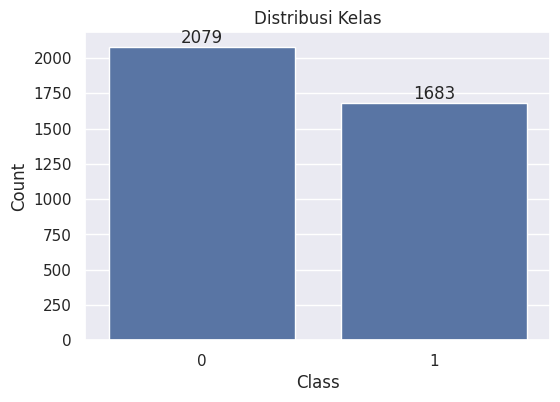

Number of Tumor Samples: 1683
Tumor Percentage: 44.74 %
Number of No Tumor Samples: 2079
No Tumor Percentage: 55.26 %


In [7]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

ax = sns.countplot(x='Class', data=df)

# Menambahkan label angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Kelas")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print('Number of Tumor Samples:', df['Class'].value_counts()[1])
print ('Tumor Percentage:', round(df['Class'].value_counts()[1]/len(df)*100,2),'%')

print('Number of No Tumor Samples:', df['Class'].value_counts()[0])
print ('No Tumor Percentage:', round(df['Class'].value_counts()[0]/len(df)*100,2),'%')

##*8. Fitur Homogeneity berdasarkan Class*

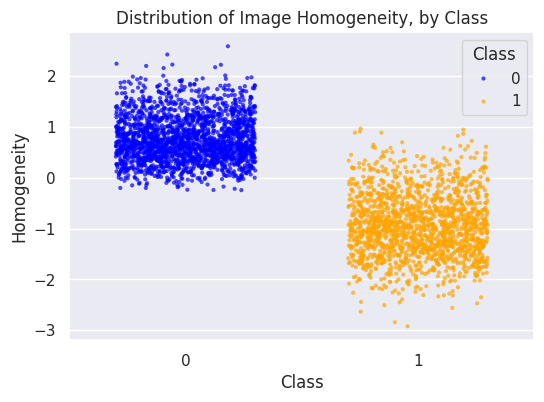

In [8]:
plt.figure(figsize=(6,4))
sns.set_style("darkgrid")

sns.stripplot(
    x='Class',
    y='Homogeneity',
    data=df,
    hue='Class',              # membedakan warna berdasarkan class
    palette=['blue', 'orange'],
    jitter=0.3,
    size=3,
    alpha=0.7,
    dodge=False
)

plt.title('Distribution of Image Homogeneity, by Class')
plt.xlabel('Class')
plt.ylabel('Homogeneity')
plt.show()

## *9. Menampilkan Distribusi fitur Mean vs Entropy vs Class*

<Axes: xlabel='Mean', ylabel='Entropy'>

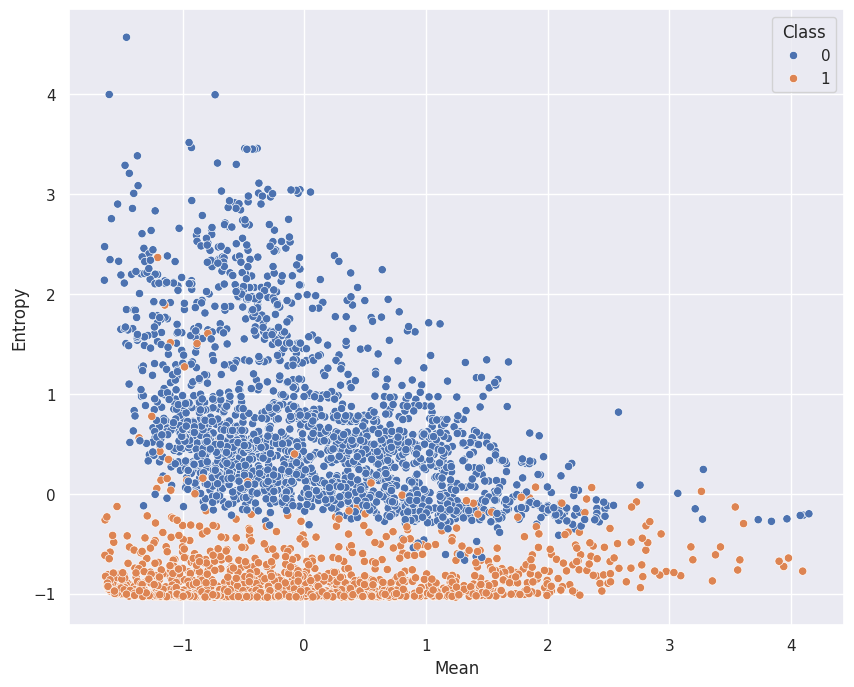

In [9]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Mean', y='Entropy', hue='Class', data=df)

##*10. Distribusi fitur Energy berdasarkan Class dan distribusi fitur Entropy berdasarkan Class*

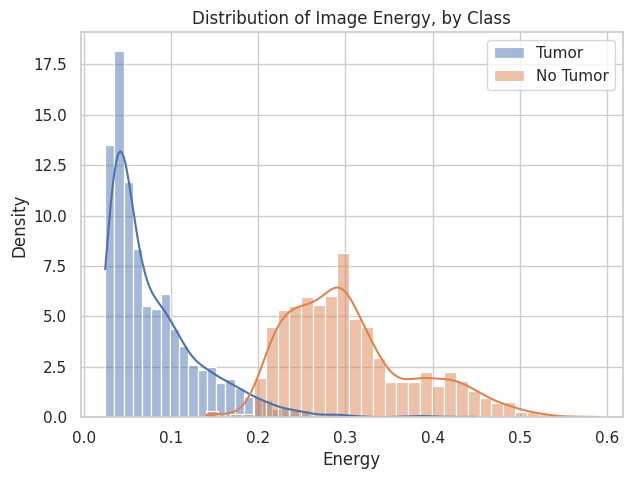

In [10]:
sns.set_style("whitegrid")

# Pisahkan data
class1 = df['Class'] == 1   # Tumor
class0 = df['Class'] == 0   # No Tumor

# Drop kolom yang tidak perlu
_data = df.drop('Image', axis=1)

# Figure
plt.figure(figsize=(7,5))

# Histogram + KDE untuk Tumor
sns.histplot(_data[class1]['Energy'],
             kde=True,
             stat="density",
             label="Tumor",
             alpha=0.5)

# Histogram + KDE untuk No Tumor
sns.histplot(_data[class0]['Energy'],
             kde=True,
             stat="density",
             label="No Tumor",
             alpha=0.5)

# Judul & label
plt.title("Distribution of Image Energy, by Class")
plt.xlabel("Energy")
plt.ylabel("Density")

# Legend
plt.legend()

plt.show()

#**Implementasi Machine Learning - Random Forest**

## *1. Memisahkan Fitur (X) dan Target (y)*

In [11]:
# Kolom 'Image' dibuang karena model hanya butuh angka, targetnya ada di 'Class'
X = df.drop(['Image', 'Class'], axis=1)
y = df['Class']

## *2. Split Data*

In [12]:
# 80% untuk Training, 20% untuk Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## *3. Training Model Random Forest*

In [13]:
# Menggunakan 100 pohon keputusan / estimasi
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## *4. Prediksi dan Evaluasi Hasil*

In [14]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model Random Forest : {accuracy * 100:.2f}%\n")

print("Classification Report : \n")
print(classification_report(y_test, y_pred))

Akurasi Model Random Forest : 98.41%

Classification Report : 

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       419
           1       0.99      0.97      0.98       334

    accuracy                           0.98       753
   macro avg       0.98      0.98      0.98       753
weighted avg       0.98      0.98      0.98       753



## *5. Visualisasi Confusion Matrix*

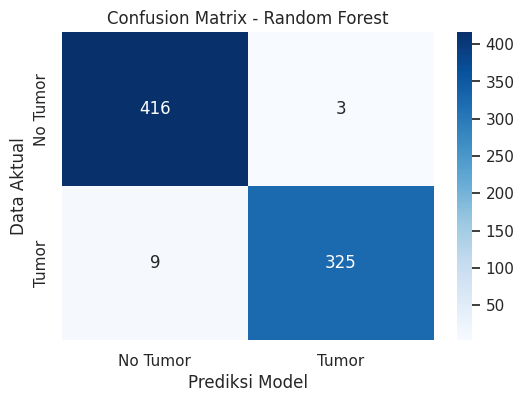

In [15]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()

## *6. Feature Importance*

/tmp/ipykernel_4128/2728221346.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




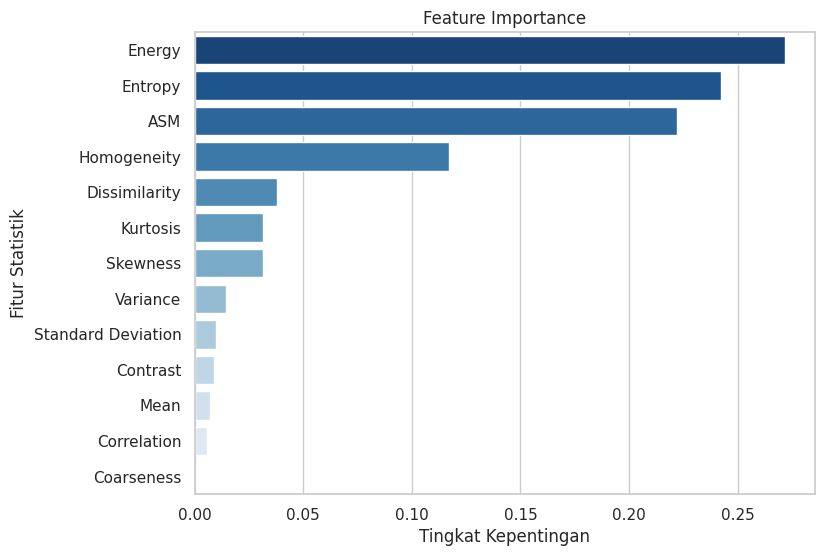

In [16]:
# Melihat fitur/kolom mana yang paling penting buat model saat menebak
importances = rf_model.feature_importances_
feature_names = X.columns

# Mengurutkan nilai dari yang paling penting
feat_imp = pd.DataFrame({'Fitur': feature_names, 'Pentingnya': importances})
feat_imp = feat_imp.sort_values(by='Pentingnya', ascending=False)

plt.figure(figsize=(8,6))
# Menggunakan palette Blues_r untuk efek gradient navy ke biru muda
sns.barplot(x='Pentingnya', y='Fitur', data=feat_imp, palette='Blues_r')
plt.title('Feature Importance')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur Statistik')
plt.show()

## *7. Kesimpulan Analisis Klasifikasi*

* **Kondisi Dataset:** Dataset yang digunakan sudah sangat representatif karena seimbang antara kelas tumor dan sehat, serta bersih dari nilai kosong (*missing values*). Hal ini membuat model bisa belajar tanpa ada kecenderungan bias ke satu sisi.
* **Pentingnya Preprocessing:** Penerapan `StandardScaler` terbukti krusial. Proses ini memastikan fitur yang punya rentang angka besar tidak "menindas" fitur yang angkanya kecil, sehingga algoritma Random Forest bisa menilai semua fitur secara proporsional.
* **Hasil Evaluasi Model:** Model Random Forest mencetak performa yang sangat memuaskan dengan tingkat **akurasi 98.41%**. Dari 753 sampel data uji, model hanya meleset 12 kali. Ini membuktikan bahwa metode *ensemble learning* sangat cocok untuk data tekstur seperti ini.
* **Fitur Indikator Terkuat:** Berdasarkan visualisasi *Feature Importance*, **Energy, ASM, dan Entropy** adalah 3 fitur yang paling dominan. Artinya, perubahan pada tingkat keseragaman (Energy/ASM) dan ketidakteraturan piksel (Entropy) pada MRI adalah tanda visual terkuat adanya tumor.
* **Potensi Implementasi Klinis:** Dengan minimnya tingkat kesalahan (*False Positive & False Negative*), pendekatan Machine Learning ini sangat berpotensi untuk dikembangkan menjadi sistem *Computer-Aided Diagnosis* (CAD). Sistem ini bisa bertindak sebagai asisten pintar bagi dokter radiologi.